   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')
Accuracy: 1.0

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



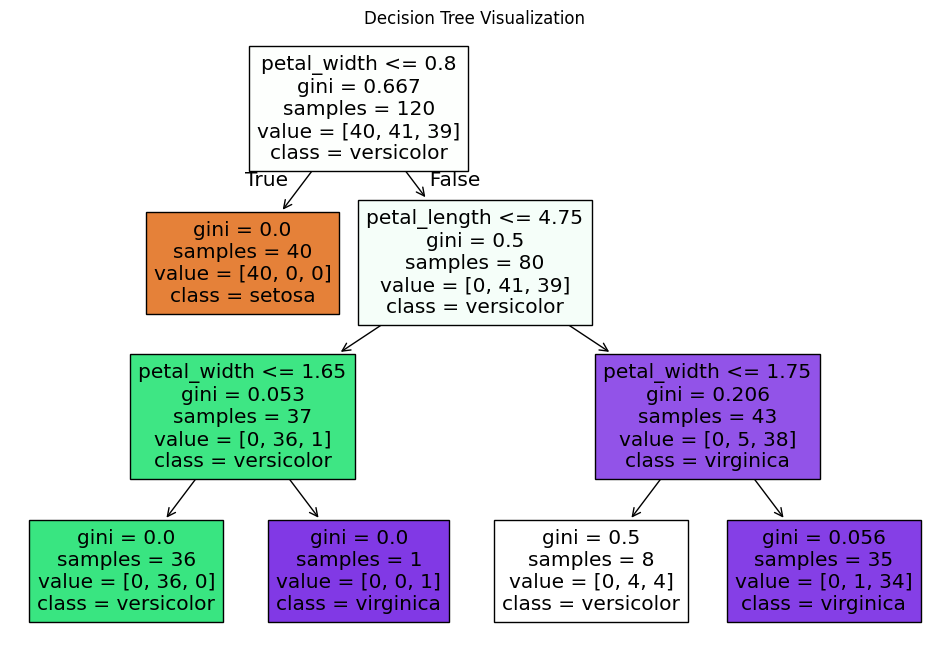

In [ ]:
# ==============================
# IMPORT LIBRARIES
# ==============================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ==============================
# LOAD DATASET
# ==============================

df = pd.read_csv('/content/1) iris.csv')

print(df.head())

# ==============================
# ENCODE TARGET COLUMN
# ==============================
print(df.columns)
encoder = LabelEncoder()

df['species'] = encoder.fit_transform(df['species'])

# ==============================
# FEATURES & TARGET
# ==============================

X = df.drop('species', axis=1)
y = df['species']

# ==============================
# TRAIN TEST SPLIT
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==============================
# TRAIN MODEL
# ==============================

model = DecisionTreeClassifier(max_depth=3)

model.fit(X_train, y_train)

# ==============================
# PREDICTIONS
# ==============================

y_pred = model.predict(X_test)

# ==============================
# EVALUATION
# ==============================

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ==============================
# VISUALIZE TREE
# ==============================

plt.figure(figsize=(12,8))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=encoder.classes_,
    filled=True
)

plt.title("Decision Tree Visualization")
plt.show()